# Лаб.3 Ульченко 24ВВИм1

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

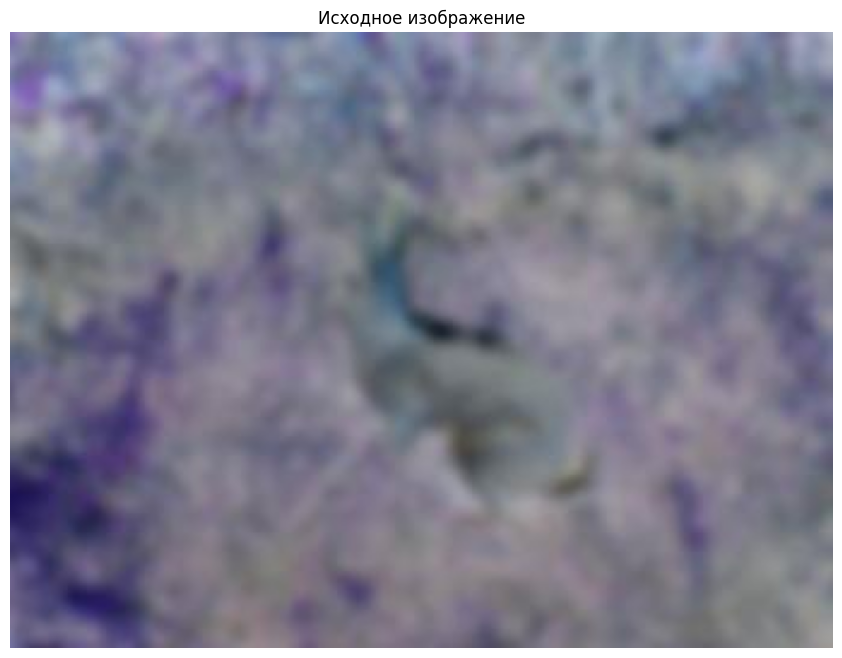

In [24]:
plt.figure(figsize=(15,8))
plt.imshow(cv.cvtColor(cv.imread('PictureForLab3.jpg'), cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Исходное изображение")
plt.show()

In [6]:
def debblur(filepath,sigma=35, boost_strength=1.8, unsharp_amount=1.0):
    img = cv.imread(filepath).astype(np.float32)
    rows, cols, _ = img.shape
    sharpened_channels = []

    for i in range(3):
        channel = img[:, :, i]
        dft = np.fft.fft2(channel)
        dft_shift = np.fft.fftshift(dft)
        y, x = np.ogrid[-rows//2:rows-rows//2, -cols//2:cols-cols//2]
        distance_squared = x*x + y*y
        low_pass = np.exp(-distance_squared / (2 * sigma**2))
        high_pass = 1.0 - low_pass
        filter_mask = 1.0 + (boost_strength - 1.0) * high_pass
        filtered = dft_shift * filter_mask
        channel_back = np.fft.ifft2(np.fft.ifftshift(filtered))
        channel_back = np.real(channel_back)
        sharpened_channels.append(channel_back)
    
    result = np.stack(sharpened_channels, axis=-1)
    result = np.clip(result, 0, 255).astype(np.uint8)
    
    if unsharp_amount > 0:
        blurred = cv.GaussianBlur(result, (0, 0), 2.5)
        result = cv.addWeighted(result, 1.0 + unsharp_amount, blurred, -unsharp_amount, 0)
    return result

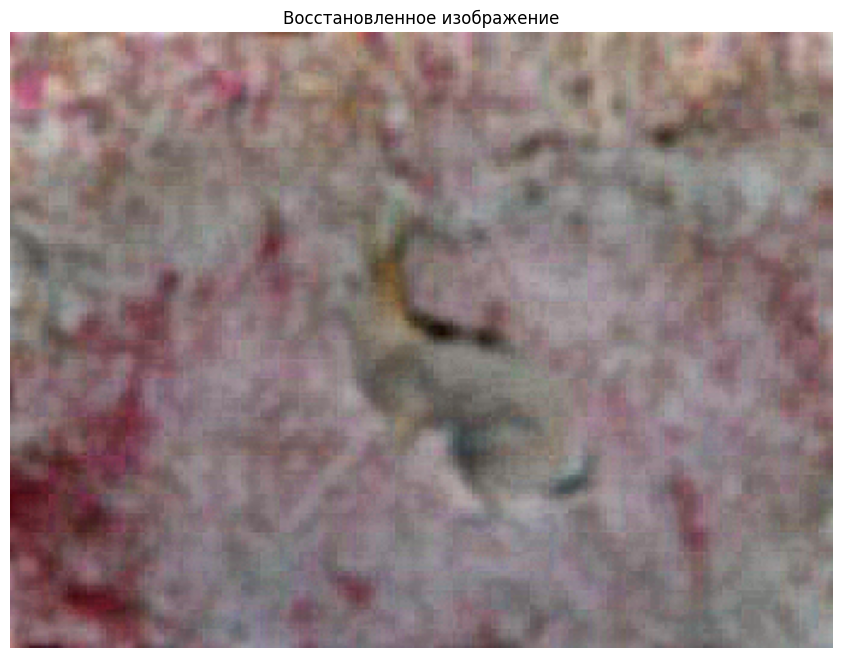

In [30]:
sharpened_rgb = debblur('PictureForLab3.jpg', sigma=25, boost_strength=1.1, unsharp_amount=2.8)

plt.figure(figsize=(15,8))
plt.imshow(sharpened_rgb)
plt.axis('off')
plt.title("Восстановленное изображение")
plt.show()